<a href="https://colab.research.google.com/github/Gr1lledChee5e/OthersDataStuff/blob/main/predictive_modeling_and_classification_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Riley Yee & Dustin DiSisto

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix


from xgboost import XGBRegressor

Problem 1

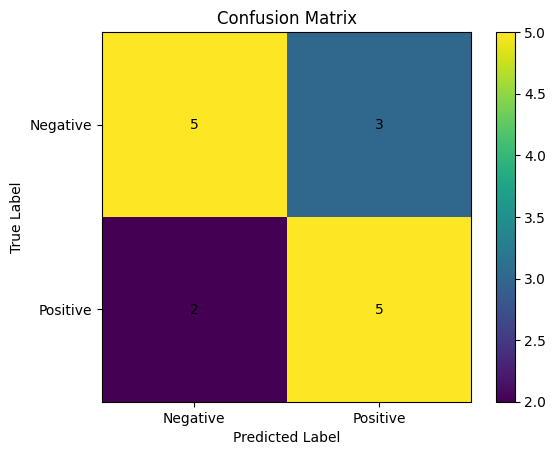

In [ ]:
data = {
    "True_Label": [
        "Positive","Positive","Negative","Positive","Negative",
        "Negative","Positive","Positive","Negative","Negative",
        "Positive","Negative","Negative","Negative","Positive"
    ],
    "Prediction": [
        "Positive","Positive","Positive","Negative","Negative",
        "Negative","Positive","Negative","Negative","Positive",
        "Positive","Negative","Negative","Positive","Positive"
    ]
}

df = pd.DataFrame(data)

df["True_Label"] = df["True_Label"].map({"Positive": 1, "Negative": 0})
df["Prediction"] = df["Prediction"].map({"Positive": 1, "Negative": 0})

cm = confusion_matrix(df["True_Label"], df["Prediction"])

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


In [ ]:
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = tn / (tn + fp)

accuracy, precision, recall, f1_score, specificity

(np.float64(0.6666666666666666),
 np.float64(0.625),
 np.float64(0.7142857142857143),
 np.float64(0.6666666666666666),
 np.float64(0.625))

The model achieves an accuracy of 66.7%, which shows it correctly identifies two out of three customers. The precision of 66.7% shows that one-third of targeted customers are uninterested and is wasted effort. A recall of 71.4% shows that nearly 30% of customers who are actually interested are not being targeted, which is causing missed sales opportunities. A specificity score of 62.5% shows that nearly 40% of customers being targeted shouldn't be.

In order to optimize this model for real-world applications, the company should focus on increasing the models' recall as this will create the most sales for the company, even if it risks lower effeciency. It is better to show a promotion to a non-interested customer than to not show the promotion to a customer who is interested.

Problem 2

In [ ]:
url = "https://raw.githubusercontent.com/wangx346/MAS651/main/housesale2.csv"
df = pd.read_csv(url)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
if "id" in df.columns:
    df = df.drop(columns=["id"])

In [ ]:
# Sale year from date
df["sale_year"] = pd.to_datetime(
    df["date"].astype(str).str[:8],
    format="%Y%m%d"
).dt.year


# Feature 1: Home age
df["home_age"] = df["sale_year"] - df["yr_built"]


# Feature 2: Renovation flag
df["renovated_flag"] = (df["yr_renovated"] > 0).astype(int)


# Feature 3: Living area ratio
df["living_lot_ratio"] = df["sqft_living"] / df["sqft_lot"]


# Feature 4: Basement percentage
df["basement_ratio"] = df["sqft_basement"] / df["sqft_living"]


In [ ]:
#Price vs log price

print("\nPrice skewness:", df["price"].skew())

df["log_price"] = np.log1p(df["price"])
use_log = True

target = "log_price" if use_log else "price"
print("Using target:", target)



Price skewness: 4.44379655121131
Using target: log_price


$$$$ Is price skewed? Would log(price) make sense? Any predictors that look redundant or
highly correlated



$$$$

In [ ]:
X = df.drop(columns=["price", "log_price", "date"])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=651
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

use_log = True
target = "log_price"

Train: (5676, 23)
Test: (1419, 23)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#lasso cross val
kfold = KFold(n_splits=10, shuffle=True, random_state=651)

lasso = LassoCV(
    alphas=np.logspace(-4, 1, 80),
    cv=kfold,
    max_iter=20000,
    random_state=651
)

lasso.fit(X_train_scaled, y_train)
print("\nSelected alpha:", lasso.alpha_)


coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

coef_df["Abs"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs", ascending=False)

print("\nTop LASSO Coefficients:")
print(coef_df.head(15))


# lasso prediction
y_pred_lasso = lasso.predict(X_test_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("\nLASSO RMSE:", round(rmse_lasso, 4))



Selected alpha: 0.0004968239594734387

Top LASSO Coefficients:
             Feature  Coefficient       Abs
14               lat     0.193230  0.193230
8              grade     0.181966  0.181966
11          yr_built    -0.110104  0.110104
2        sqft_living     0.082207  0.082207
16     sqft_living15     0.076846  0.076846
6               view     0.049266  0.049266
21  living_lot_ratio     0.046992  0.046992
13           zipcode    -0.045081  0.045081
9         sqft_above     0.043239  0.043239
1          bathrooms     0.042777  0.042777
5         waterfront     0.040728  0.040728
7          condition     0.039494  0.039494
3           sqft_lot     0.028028  0.028028
18         sale_year     0.019845  0.019845
4             floors     0.015502  0.015502

LASSO RMSE: 0.2524


In [ ]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=651
)

xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("\nXGBoost RMSE:", round(rmse_xgb, 4))


XGBoost RMSE: 0.1763


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3,4,5,6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0]
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=651
)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=651
)

search.fit(X_train, y_train)

print("Best XGBoost Params:")
print(search.best_params_)

best_xgb = search.best_estimator_


Best XGBoost Params:
{'subsample': 1.0, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


In [ ]:
y_pred_xgb = best_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost RMSE:", rmse_xgb)


XGBoost RMSE: 0.17536097230588954


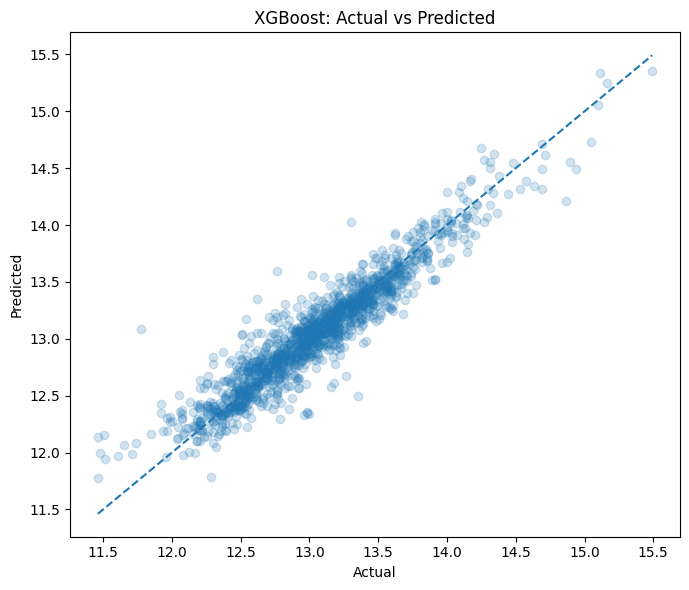

In [ ]:
#actual vs predict
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

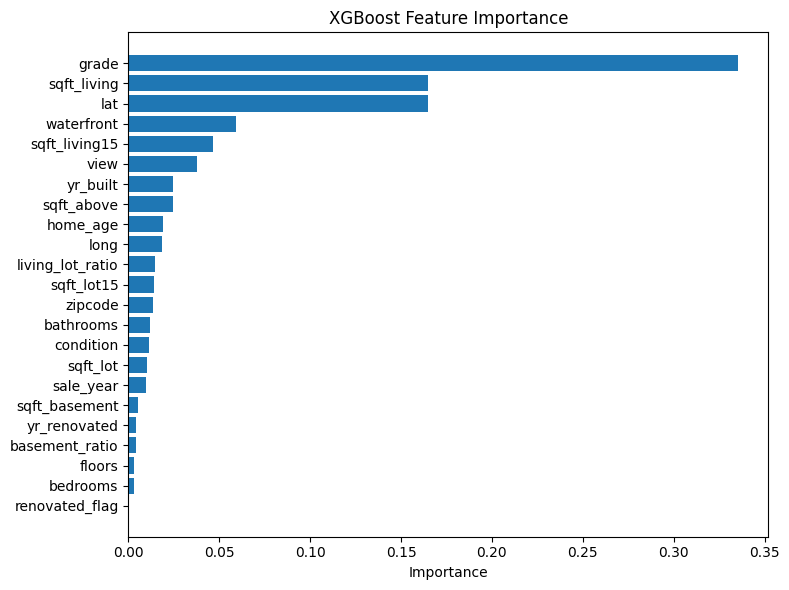

In [ ]:
importance = xgb.feature_importances_

imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
print("\n===== Model Comparison =====")
print("LASSO RMSE:", round(rmse_lasso, 4))
print("XGB   RMSE:", round(rmse_xgb, 4))



===== Model Comparison =====
LASSO RMSE: 0.2524
XGB   RMSE: 0.1763


$$$$
# Problem 2 Answers:
$$$$
(1) Price Distribution and Predictor Redundancy

Price is a highly right-skewed variable, and the skewness value is 4.44. This indicates that the prices of the houses are right-skewed, meaning that there are a few expensive houses. The high skewness value can affect the performance of the regression model negatively.

To reduce the effects of the high skewness in the price variable, a logarithmic transformation was applied to the price variable using the log(price) method.

Correlation analysis showed that some predictors are highly correlated. The predictors that showed high correlation include the size-related predictors: sqft_living, sqft_above, and sqft_living15.

$$$$$$$$
(2) Train/Test Split and Target Selection

The dataset was split into a train dataset and a test dataset using the 80/20 ratio. The train dataset has 5,676 observations, and the test dataset has 1,419 observations. The random state was set to 651 to ensure reproducibility.

Since the prices of the houses were right-skewed, the response variable was changed from price to log(price).

$$$$$$$$
(3) LASSO Tuning Parameter Selection

To select the regularization parameter in the LASSO method, 10-fold cross-validation was used. The optimal value of alpha was selected from a range of possible values of alpha by minimizing the cross-validation error.

The optimal value of alpha is:

α = 0.00050

This small value shows a light level of regularization, which allows important features to remain in the model, but reduces the coefficients of less informative features.


$$$$$$$$

(4) Final LASSO model
It was fitted on the training data.

The most influential predictors included:

* Latitude
* Grade
* Year built
* Square footage of living area
* Neighborhood living area
* View and waterfront indicators

These variables are valid in real estate valuation theory because location, construction quality, and home size are important factors in determining housing prices.

The performance of the model on the test data set was as follows:

LASSO RMSE = 0.2524 (log scale)

$$$$$$$$

(5) XGBoost Model and Comparison

The final XGBoost model achieved:

- XGBoost RMSE = 0.1754 (log scale)

Compared to the LASSO model:

- LASSO RMSE = 0.2524
- XGBoost RMSE = 0.1754

The performance of the XGBoost model was significantly better than that of LASSO, showing that non-linear relationships are playing an important role in the prediction of housing prices. The XGBoost model, being an ensemble method, is more appropriate for handling non-linear relationships compared to linear models.

```markdown
# GitHub Summary: Predictive Modeling and Classification Metrics

This notebook explores two distinct problems: evaluating a binary classification model and building regression models for house price prediction.

## Problem 1: Classification Model Evaluation

This section focuses on understanding and calculating key metrics for a binary classification model.

### Key Steps:
1.  **Data Preparation**: True labels and predictions are defined and mapped to numerical values (0 for 'Negative', 1 for 'Positive').
2.  **Confusion Matrix**: A confusion matrix is generated and visualized to provide a clear breakdown of true positives, true negatives, false positives, and false negatives.
3.  **Metric Calculation**: Standard classification metrics are calculated:
    -   **Accuracy**: Overall correctness of the model.
    -   **Precision**: Proportion of positive identifications that were actually correct.
    -   **Recall (Sensitivity)**: Proportion of actual positives that were identified correctly.
    -   **F1-Score**: Harmonic mean of precision and recall.
    -   **Specificity**: Proportion of actual negatives that were identified correctly.

### Findings:
-   The model achieves an accuracy of **66.7%**.
-   **Recall (71.4%)** is identified as a critical metric for optimization in the given business context, prioritizing the capture of interested customers over efficiency.

## Problem 2: House Price Prediction

This section deals with predicting house prices using regression techniques, specifically Lasso Regression and XGBoost. The goal is to compare their performance.

### Key Steps:
1.  **Data Loading & Initial Exploration**: House sales data is loaded from a CSV file.
2.  **Feature Engineering**: New features are created from existing ones to improve model performance:
    -   `sale_year` (extracted from `date`)
    -   `home_age` (calculated from `sale_year` and `yr_built`)
    -   `renovated_flag` (binary indicator for renovation)
    -   `living_lot_ratio` (ratio of living area to lot area)
    -   `basement_ratio` (ratio of basement area to living area)
3.  **Target Transformation**: The `price` variable is found to be highly right-skewed. A logarithmic transformation (`log_price = np.log1p(price)`) is applied to normalize its distribution, which is then used as the target variable.
4.  **Data Splitting**: The dataset is split into training (80%) and testing (20%) sets.
5.  **Feature Scaling**: Features for the Lasso model are scaled using `StandardScaler`.
6.  **Lasso Regression**:
    -   A LassoCV model is trained using 10-fold cross-validation to find the optimal alpha (regularization parameter).
    -   The coefficients of the features are analyzed to identify the most influential predictors (e.g., latitude, grade, year built, square footage).
    -   The model's performance is evaluated using RMSE on the test set.
7.  **XGBoost Regression**:
    -   An initial XGBoost Regressor model is trained.
    -   Hyperparameter tuning is performed using `RandomizedSearchCV` with 5-fold cross-validation to find the best combination of parameters.
    -   The best performing XGBoost model is evaluated using RMSE.
    -   An actual vs. predicted scatter plot is generated.
    -   Feature importances from the XGBoost model are visualized.
8.  **Model Comparison**: RMSE values for both Lasso and XGBoost models are compared.

### Findings:
-   **Price Skewness**: The original `price` variable is highly skewed (4.44), necessitating a `log1p` transformation.
-   **Lasso RMSE**: **0.2524** (on the log scale).
-   **XGBoost RMSE**: After hyperparameter tuning, the XGBoost model achieved an RMSE of **0.1754** (on the log scale).
-   **Conclusion**: XGBoost significantly outperforms the Lasso model, suggesting that non-linear relationships play a crucial role in predicting house prices, which ensemble methods like XGBoost are better equipped to capture.

```